In [1]:
import ast
import copy
import os
import random
import subprocess
import sys
import tempfile
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not ((repo_root / 'src' / 'genkit').exists() and (repo_root / 'sandbox').exists()):
    repo_root = repo_root.parent

for path_entry in [repo_root, repo_root / 'src']:
    if str(path_entry) not in sys.path:
        sys.path.insert(0, str(path_entry))

vendor_root = repo_root / 'src' / 'genkit' / '_vendor' / 'DLPM'
if str(vendor_root) not in sys.path:
    sys.path.insert(0, str(vendor_root))

from genkit.diffusion import DLPMEps, DDPMV
from genkit.thirdparty import DLPMEpsOrigin
from labkit.report import PRETTY_RCPARAMS
from dlpm.models.Model import MLPModel as VendorMLPModel
from dlpm.methods.GenerativeLevyProcess import GenerativeLevyProcess
from bem.datasets.Distributions import gen_sas
import yaml

In [ ]:
plt.rcParams.update(PRETTY_RCPARAMS)

vendor_config_path = repo_root / 'src' / 'genkit' / '_vendor' / 'DLPM' / 'dlpm' / 'configs' / '2d_sas.yml'
vendor_base_config = yaml.safe_load(vendor_config_path.read_text())

torch.set_num_threads(max(1, min(8, torch.get_num_threads())))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fdtype = torch.float32
idtype = torch.int32

N_SEEDS = 20
SEEDS = list(range(N_SEEDS))
MODEL_ALPHAS = [1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
METHODS = ['DDPMV', 'DLPMEps', 'DLPMEpsOrig']
TRAIN_SIZE = 32_000
EVAL_SIZE = 15_000
BATCH_SIZE = 1024
N_EPOCHS = 20
DIFFUSION_STEPS = 100
LEARNING_RATE = 5e-3
ALPHA_DATA = 1.7
DATA_SCALE = 0.1
XI = 0.95

In [4]:
def set_seed(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def sample_target_sas(*, n_samples: int, alpha: float, scale: float, seed: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    set_seed(seed)
    x = scale * gen_sas(alpha=alpha, size=(int(n_samples), 2), device=device, isotropic=True)
    return x.to(device=device, dtype=dtype)


def msle(x_real: torch.Tensor, x_gen: torch.Tensor, xi: float = 0.95, m: int = 1000) -> float:
    """Compute MSLE: MSLE(xi) = integral from xi to 1 of (log Q_real(p) - log Q_gen(p))^2 dp."""
    x_real = x_real.detach().cpu().numpy()
    x_gen = x_gen.detach().cpu().numpy()

    j = np.arange(1, m + 1)
    p = xi + (j - 0.5) / m * (1 - xi)

    msle_per_dim = []
    for d in range(x_real.shape[1]):
        q_real = np.quantile(np.abs(x_real[:, d]), p)
        q_gen = np.quantile(np.abs(x_gen[:, d]), p)
        q_real = np.clip(q_real, 1e-12, None)
        q_gen = np.clip(q_gen, 1e-12, None)
        integrand = (np.log(q_real) - np.log(q_gen)) ** 2
        msle_d = (1 - xi) / m * np.sum(integrand)
        msle_per_dim.append(msle_d)

    return float(np.mean(msle_per_dim))


def styled_table(ax, cell_text, row_labels, col_labels, *, fontsize: float = 8.5, scale: tuple[float, float] = (1.0, 1.35), corner_text=None):
    ax.axis('off')
    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(*scale)
    if corner_text is not None:
        corner_width = table[(1, -1)].get_width() if (1, -1) in table.get_celld() else table[(1, 0)].get_width()
        corner_height = table[(0, 0)].get_height()
        table.add_cell(0, -1, width=corner_width, height=corner_height, text=corner_text, loc='center')
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('0.2')
        cell.set_linewidth(0.6)
        if row == 0 or col == -1:
            cell.set_text_props(weight='bold')
    return table


def build_vendor_param_dict(*, model_alpha: float, device: torch.device) -> dict:
    p = copy.deepcopy(vendor_base_config)
    p['device'] = str(device)
    p['method'] = 'dlpm'
    p['data']['dataset'] = 'sas'
    p['data']['data_alpha'] = float(ALPHA_DATA)
    p['data']['std'] = float(DATA_SCALE)
    p['data']['dim'] = 2
    p['data']['nfeatures'] = 2
    p['data']['nsamples'] = int(TRAIN_SIZE)
    p['data']['isotropic'] = True
    p['data']['normalized'] = False
    p['dlpm']['alpha'] = float(model_alpha)
    p['dlpm']['reverse_steps'] = int(DIFFUSION_STEPS)
    p['dlpm']['isotropic'] = True
    p['dlpm']['mean_predict'] = 'EPSILON'
    p['dlpm']['var_predict'] = 'FIXED'
    p['dlpm']['rescale_timesteps'] = True
    p['dlpm']['scale'] = 'scale_preserving'
    p['dlpm']['input_scaling'] = False
    p['training']['batch_size'] = int(BATCH_SIZE)
    p['training']['num_workers'] = 0
    p['training']['dlpm']['loss_monte_carlo'] = 'mean'
    p['training']['dlpm']['loss_type'] = 'EPS_LOSS'
    p['training']['dlpm']['lploss'] = 2.0
    p['training']['dlpm']['monte_carlo_inner'] = 1
    p['training']['dlpm']['monte_carlo_outer'] = 1
    p['optim']['optimizer'] = 'adamw'
    p['optim']['lr'] = float(LEARNING_RATE)
    p['run']['epochs'] = int(N_EPOCHS)
    return p


class Vendor2DAdapter(torch.nn.Module):
    def __init__(self, vendor_param_dict: dict):
        super().__init__()
        self.vendor_param_dict = copy.deepcopy(vendor_param_dict)
        self.core = VendorMLPModel(self.vendor_param_dict)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if x.ndim == 2:
            x = x.unsqueeze(1)
        if isinstance(t, torch.Tensor):
            if t.ndim == 2 and t.shape[1] == 1:
                t = t.squeeze(-1)
            elif t.ndim > 1:
                t = t.reshape(t.shape[0])
        y = self.core(x, t)
        if y.ndim == 3 and y.shape[1] == 1:
            y = y.squeeze(1)
        elif y.ndim == 4 and y.shape[1:3] == (1, 1):
            y = y.squeeze(1).squeeze(1)
        return y


def build_models(*, model_alpha: float, seed: int, device: torch.device) -> dict[str, object]:
    p = build_vendor_param_dict(model_alpha=model_alpha, device=device)

    # DDPMV (Gaussian diffusion baseline - does not use model_alpha)
    set_seed(seed)
    ddpmv = DDPMV(
        net=Vendor2DAdapter(p),
        dim=2,
        n_steps=DIFFUSION_STEPS,
        fdtype=fdtype,
        idtype=idtype,
        device=device,
    )

    # DLPMEps (our implementation)
    set_seed(seed)
    native = DLPMEps(
        net=Vendor2DAdapter(p),
        dim=2,
        n_steps=DIFFUSION_STEPS,
        alpha=model_alpha,
        n_trial_A=1,
        n_trial_G=1,
        reduce_type='mean',
        fdtype=fdtype,
        idtype=idtype,
        device=device,
    )

    # DLPMEpsOrig (vendor code wrapper)
    set_seed(seed)
    origin = DLPMEpsOrigin(
        net=Vendor2DAdapter(p),
        dim=2,
        n_steps=DIFFUSION_STEPS,
        alpha=model_alpha,
        loss_monte_carlo='mean',
        monte_carlo_outer=1,
        monte_carlo_inner=1,
        lploss=2.0,
        scale='scale_preserving',
        fdtype=fdtype,
        idtype=idtype,
        device=device,
    )

    return {'DDPMV': ddpmv, 'DLPMEps': native, 'DLPMEpsOrig': origin, 'vendor_param_dict': p}


def train_epochs(model, x_train: torch.Tensor, *, seed: int, batch_size: int, n_epochs: int, lr: float) -> list[float]:
    dataset = TensorDataset(x_train.detach().cpu())
    generator = torch.Generator(device='cpu')
    generator.manual_seed(int(seed))
    loader = DataLoader(dataset, batch_size=int(batch_size), shuffle=True, drop_last=False, generator=generator, num_workers=0)
    optimizer = torch.optim.AdamW(model._net.parameters(), lr=float(lr))
    step_losses = []

    model._net.train()
    for _ in range(int(n_epochs)):
        for (xb,) in loader:
            xb = xb.to(device=device, dtype=fdtype)
            optimizer.zero_grad(set_to_none=True)
            loss = model.loss(xb)
            loss.backward()
            optimizer.step()
            step_losses.append(float(loss.detach().cpu()))

    return step_losses


@torch.no_grad()
def evaluate_msle(model, x_eval: torch.Tensor, xi: float = XI) -> float:
    model._net.eval()
    x_gen = model.sample(int(x_eval.shape[0]))
    return msle(x_eval, x_gen, xi=xi)


def run_one(*, method_name: str, model_alpha: float, seed: int) -> dict:
    x_train = sample_target_sas(n_samples=TRAIN_SIZE, alpha=ALPHA_DATA, scale=DATA_SCALE, seed=seed, device=device, dtype=fdtype)
    x_eval = sample_target_sas(n_samples=EVAL_SIZE, alpha=ALPHA_DATA, scale=DATA_SCALE, seed=100_000 + seed, device=device, dtype=fdtype)

    built = build_models(model_alpha=model_alpha, seed=seed, device=device)
    model = built[method_name]
    step_losses = train_epochs(model, x_train, seed=seed, batch_size=BATCH_SIZE, n_epochs=N_EPOCHS, lr=LEARNING_RATE)
    msle95 = evaluate_msle(model, x_eval, xi=XI)

    return {
        'method': method_name,
        'model_alpha': float(model_alpha),
        'seed': int(seed),
        'msle95': float(msle95),
        'loss_last': float(step_losses[-1]),
        'n_steps': len(step_losses),
    }


def run_full_sweep() -> pd.DataFrame:
    rows = []
    total = len(METHODS) * len(MODEL_ALPHAS) * len(SEEDS)
    progress = tqdm(total=total, desc='tail-coverage sweep')
    for method_name in METHODS:
        for model_alpha in MODEL_ALPHAS:
            for seed in SEEDS:
                row = run_one(method_name=method_name, model_alpha=model_alpha, seed=seed)
                rows.append(row)
                progress.update(1)
    progress.close()
    return pd.DataFrame(rows).sort_values(['method', 'model_alpha', 'seed']).reset_index(drop=True)

In [5]:
run_df = run_full_sweep()

tail-coverage sweep: 100%|██████████| 18/18 [06:48<00:00, 22.70s/it]


In [6]:
AUTHOR_METHOD = 'DLPMAuthor'
AUTHOR_CONFIG_NAME = '2d_sas'
AUTHOR_CONFIG_DIR = vendor_root / 'dlpm' / 'configs'
AUTHOR_CONFIG_PATH = AUTHOR_CONFIG_DIR / f'{AUTHOR_CONFIG_NAME}.yml'


def build_author_model(*, model_alpha: float, device: torch.device) -> VendorMLPModel:
    p = build_vendor_param_dict(model_alpha=model_alpha, device=device)
    return VendorMLPModel(p).to(device)


def build_author_sampler(*, model_alpha: float, device: torch.device) -> GenerativeLevyProcess:
    return GenerativeLevyProcess(
        alpha=float(model_alpha),
        device=device,
        reverse_steps=int(DIFFUSION_STEPS),
        rescale_timesteps=True,
        isotropic=True,
        scale='scale_preserving',
    )


def _parse_vendor_save_tuple(stdout: str) -> tuple[Path, Path, Path]:
    for line in reversed(stdout.splitlines()):
        line = line.strip()
        if line.startswith('(') and line.endswith(')'):
            maybe_paths = ast.literal_eval(line)
            if isinstance(maybe_paths, tuple) and len(maybe_paths) == 3:
                return tuple(Path(p) for p in maybe_paths)
    raise RuntimeError(f'Could not parse the vendor save tuple from stdout:\n{stdout}')


def _parse_last_epoch_loss(stdout: str) -> float:
    for line in reversed(stdout.splitlines()):
        line = line.strip()
        if line.startswith('epoch_loss '):
            return float(line.split()[-1])
    return float('nan')


def run_author_one(*, model_alpha: float, seed: int) -> dict:
    alpha_tag = f'{model_alpha:.1f}'.replace('.', 'p')
    run_name = f'author_sas_alpha_{alpha_tag}_seed_{seed}'
    script = (
        'import sys\n'
        f'sys.path.insert(0, {str(vendor_root)!r})\n'
        'from run import run_exp\n'
        f'run_exp({str(AUTHOR_CONFIG_DIR)!r})\n'
    )
    cmd = [
        sys.executable,
        '-c',
        script,
        '--config', AUTHOR_CONFIG_NAME,
        '--name', run_name,
        '--method', 'dlpm',
        '--set_seed', str(int(seed)),
        '--alpha', str(float(model_alpha)),
        '--epochs', str(int(N_EPOCHS)),
        '--train_reverse_steps', str(int(DIFFUSION_STEPS)),
        '--reverse_steps', str(int(DIFFUSION_STEPS)),
        '--data_std', str(float(DATA_SCALE)),
        '--nsamples', str(int(TRAIN_SIZE)),
        '--dataset', 'sas',
        '--lr', str(float(LEARNING_RATE)),
        '--no_ema_eval',
    ]

    with tempfile.TemporaryDirectory(prefix='dlpm_author_', dir='/tmp') as tmpdir:
        mplconfig_dir = Path(tmpdir) / '.mplconfig'
        mplconfig_dir.mkdir(parents=True, exist_ok=True)
        env = os.environ.copy()
        env['MPLCONFIGDIR'] = str(mplconfig_dir)
        proc = subprocess.run(cmd, cwd=tmpdir, capture_output=True, text=True, check=True, env=env)
        model_path_rel, _, _ = _parse_vendor_save_tuple(proc.stdout)
        checkpoint = torch.load(Path(tmpdir) / model_path_rel, map_location=device, weights_only=False)

        author_model = build_author_model(model_alpha=model_alpha, device=device)
        author_model.load_state_dict(checkpoint['model_parameters'])
        author_model.eval()

        x_eval = sample_target_sas(
            n_samples=EVAL_SIZE,
            alpha=ALPHA_DATA,
            scale=DATA_SCALE,
            seed=100_000 + seed,
            device=device,
            dtype=fdtype,
        )
        set_seed(seed)
        author_sampler = build_author_sampler(model_alpha=model_alpha, device=device)
        with torch.no_grad():
            x_gen = author_sampler.p_sample_loop(
                author_model,
                shape=(int(x_eval.shape[0]), 1, int(x_eval.shape[1])),
                progress=False,
            )
        if x_gen.ndim == 3 and x_gen.shape[1] == 1:
            x_gen = x_gen.squeeze(1)

        msle95 = msle(x_eval, x_gen, xi=XI)

    return {
        'method': AUTHOR_METHOD,
        'model_alpha': float(model_alpha),
        'seed': int(seed),
        'msle95': float(msle95),
        'loss_last': _parse_last_epoch_loss(proc.stdout),
        'n_steps': int(checkpoint['steps']),
    }


def run_author_sweep() -> pd.DataFrame:
    rows = []
    total = len(MODEL_ALPHAS) * len(SEEDS)
    progress = tqdm(total=total, desc='dlpm author sweep')
    for model_alpha in MODEL_ALPHAS:
        for seed in SEEDS:
            row = run_author_one(model_alpha=model_alpha, seed=seed)
            rows.append(row)
            progress.update(1)
    progress.close()
    return pd.DataFrame(rows).sort_values(['method', 'model_alpha', 'seed']).reset_index(drop=True)


author_run_df = run_author_sweep()

dlpm author sweep: 100%|██████████| 6/6 [03:39<00:00, 36.59s/it]


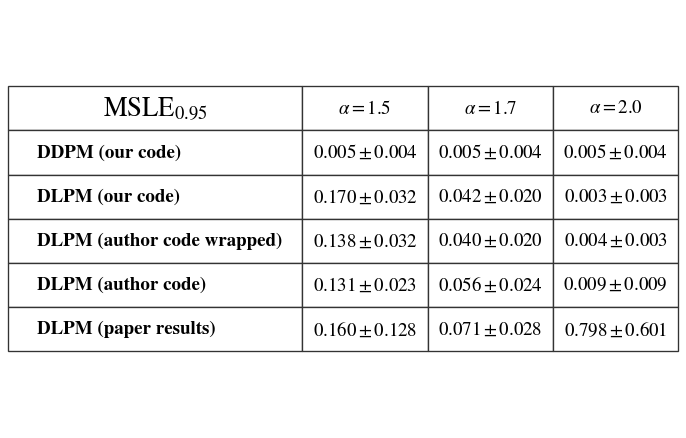

In [8]:
combined_df = pd.concat([run_df, author_run_df], ignore_index=True)
summary_df = (
    combined_df.groupby(['model_alpha', 'method'], as_index=False)
    .agg(msle95_mean=('msle95', 'mean'), msle95_std=('msle95', 'std'))
    .sort_values(['model_alpha', 'method'])
    .reset_index(drop=True)
)

METHOD_LABELS = {
    'DDPMV': 'DDPM (our code)',
    'DLPMEps': 'DLPM (our code)',
    'DLPMEpsOrig': 'DLPM (author code wrapped)',
    'DLPMAuthor': 'DLPM (author code)',
}
PAPER_VALUES = {
    1.5: (0.160, 0.128),
    1.6: (0.081, 0.078),
    1.7: (0.071, 0.028),
    1.8: (0.099, 0.044),
    1.9: (0.132, 0.101),
    2.0: (0.798, 0.601),
}

row_labels = [METHOD_LABELS[m] for m in METHODS] + [METHOD_LABELS[AUTHOR_METHOD], 'DLPM (paper results)']
table_df = pd.DataFrame(
    'NA',
    index=row_labels,
    columns=[f'$\\alpha = {alpha:.1f}$' for alpha in MODEL_ALPHAS],
    dtype=object,
)

for _, row in summary_df.iterrows():
    label = METHOD_LABELS[row['method']]
    col = f'$\\alpha = {float(row["model_alpha"]):.1f}$'
    table_df.loc[label, col] = f'${row["msle95_mean"]:.3f} \\pm {row["msle95_std"]:.3f}$'

for alpha in MODEL_ALPHAS:
    mean, std = PAPER_VALUES[alpha]
    col = f'$\\alpha = {alpha:.1f}$'
    table_df.loc['DLPM (paper results)', col] = f'${mean:.3f} \\pm {std:.3f}$'

fig, ax = plt.subplots(1, 1, figsize=(0.95 + 1.2 * len(table_df.columns), 0.9 + 0.42 * len(table_df.index)))
styled_table(
    ax,
    table_df.values,
    list(table_df.index),
    list(table_df.columns),
    fontsize=8.5,
    scale=(1.0, 1.45),
    corner_text=r'$\mathrm{MSLE}_{0.95}$',
)
fig.tight_layout()
plt.show()